In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("/content/Crop_recommendation.csv")

In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df.shape

(2200, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
df["label"].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [ ]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


<Axes: >

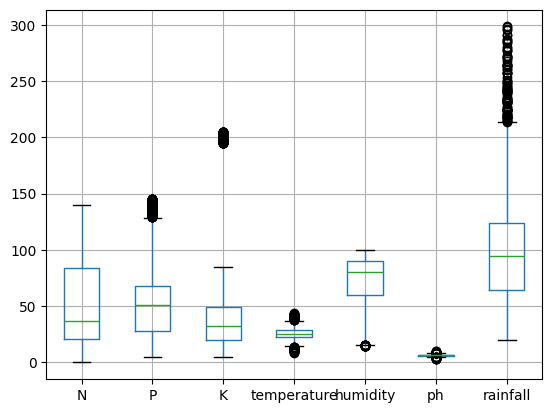

In [ ]:
df.boxplot()

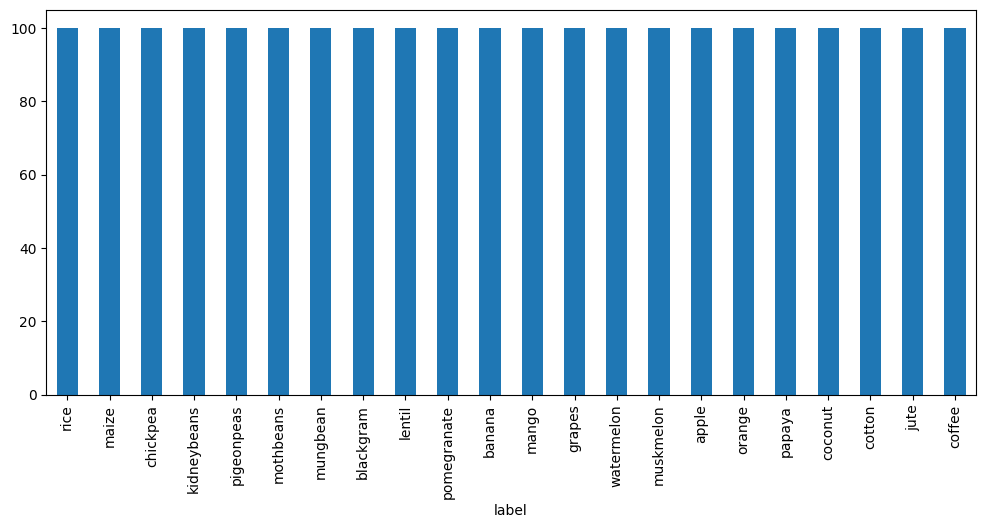

In [ ]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar", figsize=(12,5))
plt.xticks(rotation=90)
plt.show()

array([[<Axes: title={'center': 'N'}>, <Axes: title={'center': 'P'}>,
        <Axes: title={'center': 'K'}>],
       [<Axes: title={'center': 'temperature'}>,
        <Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'ph'}>],
       [<Axes: title={'center': 'rainfall'}>, <Axes: >, <Axes: >]],
      dtype=object)

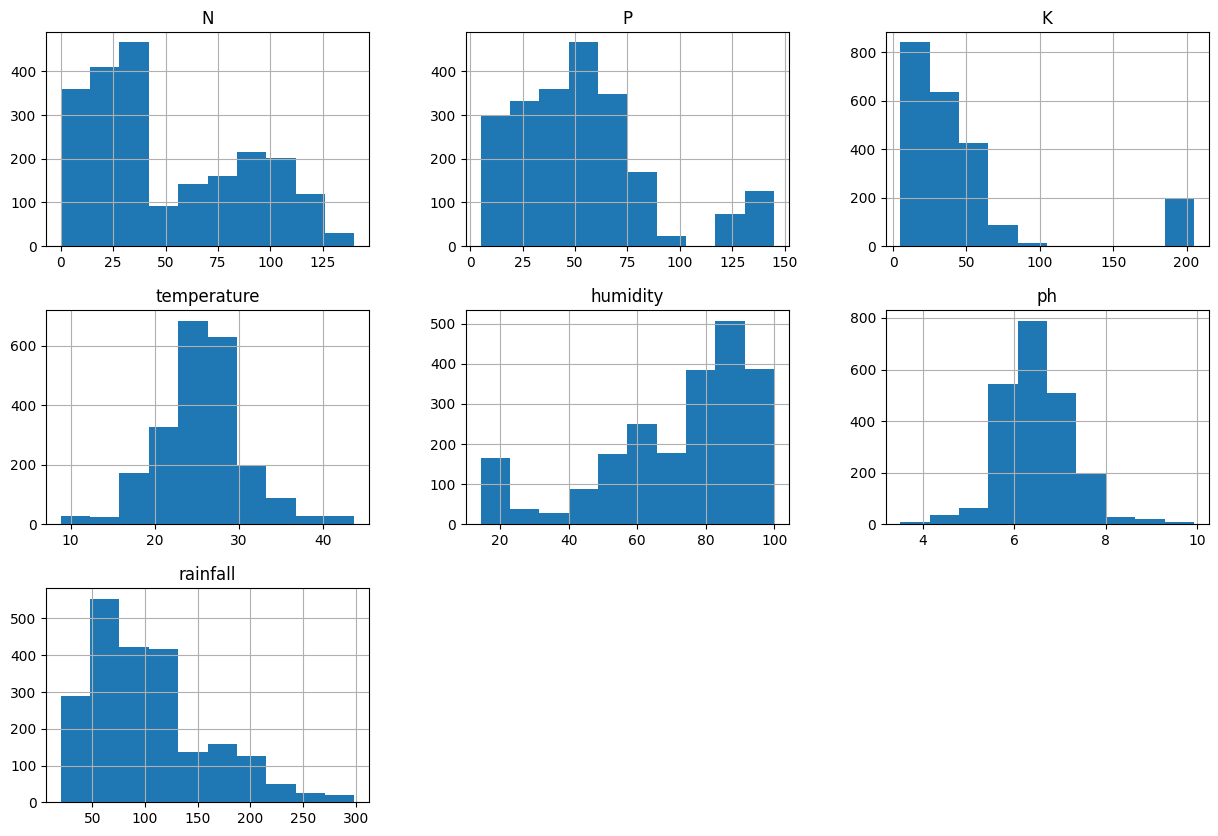

In [ ]:
df.hist(figsize=(15,10))

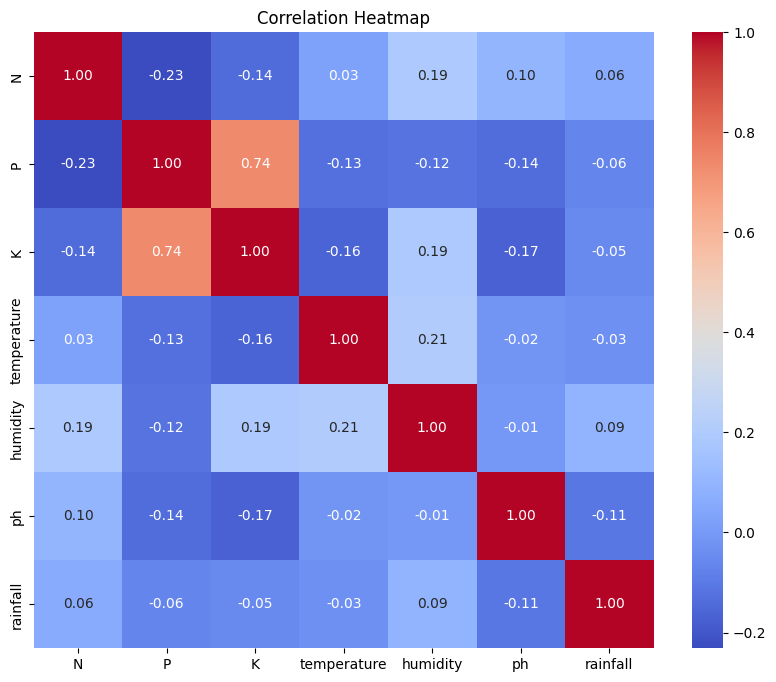

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("label", axis=1).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
'''## Correlation Analysis

- Most features have weak correlations with each other.
- Phosphorus and Potassium show the strongest positive relationship (~0.74).
- Temperature has little correlation with the remaining variables.
- Rainfall and pH appear largely independent.
- Overall, the dataset has low multicollinearity, suggesting that most features contribute unique information to the machine learning model.
'''

'## Correlation Analysis\n\n- Most features have weak correlations with each other.\n- Phosphorus and Potassium show the strongest positive relationship (~0.74).\n- Temperature has little correlation with the remaining variables.\n- Rainfall and pH appear largely independent.\n- Overall, the dataset has low multicollinearity, suggesting that most features contribute unique information to the machine learning model.\n'

In [ ]:
X = df.drop("label", axis=1)

y = df["label"]

In [ ]:
X

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [ ]:
y

,label
0,rice
1,rice
2,rice
3,rice
4,rice
...,...
2195,coffee
2196,coffee
2197,coffee
2198,coffee


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1760, 7)
(440, 7)
(1760,)
(440,)


''' Observation

The dataset was divided into

1760 training samples

440 testing samples.

The training dataset will be used
to learn patterns.

The testing dataset will evaluate
whether the model can predict unseen data.
'''

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

This is the learning phase.

The algorithm studies the 1,760 training examples.

In [ ]:
y_pred= model.predict(X_test)

Now the model is taking its final exam.

It predicts the crops for the 440 rows it has never seen before.

In [ ]:
print(y_pred[:10])
print(y_test.iloc[:10].values)

['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil']
['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple' 'mango' 'apple'
 'mothbeans' 'mungbean' 'lentil']


q1

.fit() is the learning phase, where the algorithm studies the training data to identify patterns between the input features and the target variable. .predict() is the inference phase, where the trained model applies those learned patterns to make predictions on new, unseen data.

q2

A trained model stores the parameters or structure learned during training. In Random Forest, this consists of multiple decision trees that have learned how different feature values lead to different crop predictions. These learned structures are then used to make predictions on new data.

q3 -why random forest best model

Random Forest

Random Forest is great because

✅ Works well on structured/tabular data.

✅ Handles nonlinear relationships.

Example

Temperature

↓

Rainfall

↓

Humidity

↓

Crop

The relationship isn't a straight line.

Random Forest captures that.

The Lesson

A model with 99% accuracy can still be terrible if it consistently misses the important cases.

That's why professional ML engineers don't stop at accuracy.

They also examine:

# **Confusion Matrix** – What kinds of mistakes did the model make?
# **Precision** – When the model predicts a class, how often is it right?
# **Recall** – How many of the actual cases did the model find?
# **F1 Score** – A balance between precision and recall.

An ML Engineer thinks:

What mistakes is the model making?

↓

Are those mistakes acceptable?

↓

Can users trust the predictions?

## **Model_Evaluation**



Chapter 1

✅ Accuracy

Chapter 2

✅ Confusion Matrix

You'll actually see where the model makes mistakes.

Chapter 3

✅ Precision

Not just:

How many predictions were correct?

But:

When the model predicts Rice, how often is it actually Rice?

Chapter 4

✅ Recall

Can the model find all the Rice samples?

Chapter 5

✅ F1 Score

Balances Precision and Recall.

Chapter 6

✅ Classification Report

A complete report of how well the model performs for each crop.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9931818181818182


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

**Precision** asks

How many predictions were actually correct?

manam kanipetinadantlo enni correct vuunai ??

**Recall** asks

How many did we find?
manam enni kani petinam ???

**support**  ante total enni vunai ani --- 19  total

**recall**    ante kanipetinavi enn acutal ga total lo ani 89 % kanipetinam mean 17 anuko

**precision** ante kanipettinavi enntha accurate ga vunai ani ---1.0% mean enni 17 lo 17 correct ga vunnai ani

In [ ]:
'''
Accuracy	        Overall, how often was the model correct?
Precision	        When the model predicts a class, how often is it right?
Recall	          Out of all the actual instances of a class, how many did the model find?
F1-score        	How well does the model balance precision and recall?
Support         	How many actual examples of this class were in the test set?
'''

'\nAccuracy\t        Overall, how often was the model correct?\nPrecision\t        When the model predicts a class, how often is it right?\nRecall\t          Out of all the actual instances of a class, how many did the model find?\nF1-score        \tHow well does the model balance precision and recall?\nSupport         \tHow many actual examples of this class were in the test set?\n'

In [ ]:
''' Accuracy (The Simplest Metric)

Imagine your OptiCrop model tested 100 farms.

Out of those:

95 predictions are correct ✅
5 predictions are wrong ❌

Then

Accuracy = Correct Predictions / Total Predictions

Accuracy = 95 / 100 = 95%

That's all accuracy measures.

Think of Accuracy as

"Overall, how often was my model correct?"

It doesn't care which crops were wrong.'''

' Accuracy (The Simplest Metric)\n\nImagine your OptiCrop model tested 100 farms.\n\nOut of those:\n\n95 predictions are correct ✅\n5 predictions are wrong ❌\n\nThen\n\nAccuracy = Correct Predictions / Total Predictions\n\nAccuracy = 95 / 100 = 95%\n\nThat\'s all accuracy measures.\n\nThink of Accuracy as\n\n"Overall, how often was my model correct?"\n\nIt doesn\'t care which crops were wrong.'

In [ ]:
'''
 F1-Score (The Balance)

Think of Precision and Recall as two friends.

Suppose

Precision = 100%

Recall = 20%

Meaning

Every time the model predicts Rice,

it's correct.

BUT

It only finds 20% of all Rice farms.

That's not a good model.

Another model

Precision = 90%

Recall = 90%

Much better.

F1 Score says:

"I want a model that is good at both Precision and Recall."

It combines both into one balanced score.
'''

'\n F1-Score (The Balance)\n\nThink of Precision and Recall as two friends.\n\nSuppose\n\nPrecision = 100%\n\nRecall = 20%\n\nMeaning\n\nEvery time the model predicts Rice,\n\nit\'s correct.\n\nBUT\n\nIt only finds 20% of all Rice farms.\n\nThat\'s not a good model.\n\nAnother model\n\nPrecision = 90%\n\nRecall = 90%\n\nMuch better.\n\nF1 Score says:\n\n"I want a model that is good at both Precision and Recall."\n\nIt combines both into one balanced score.\n'

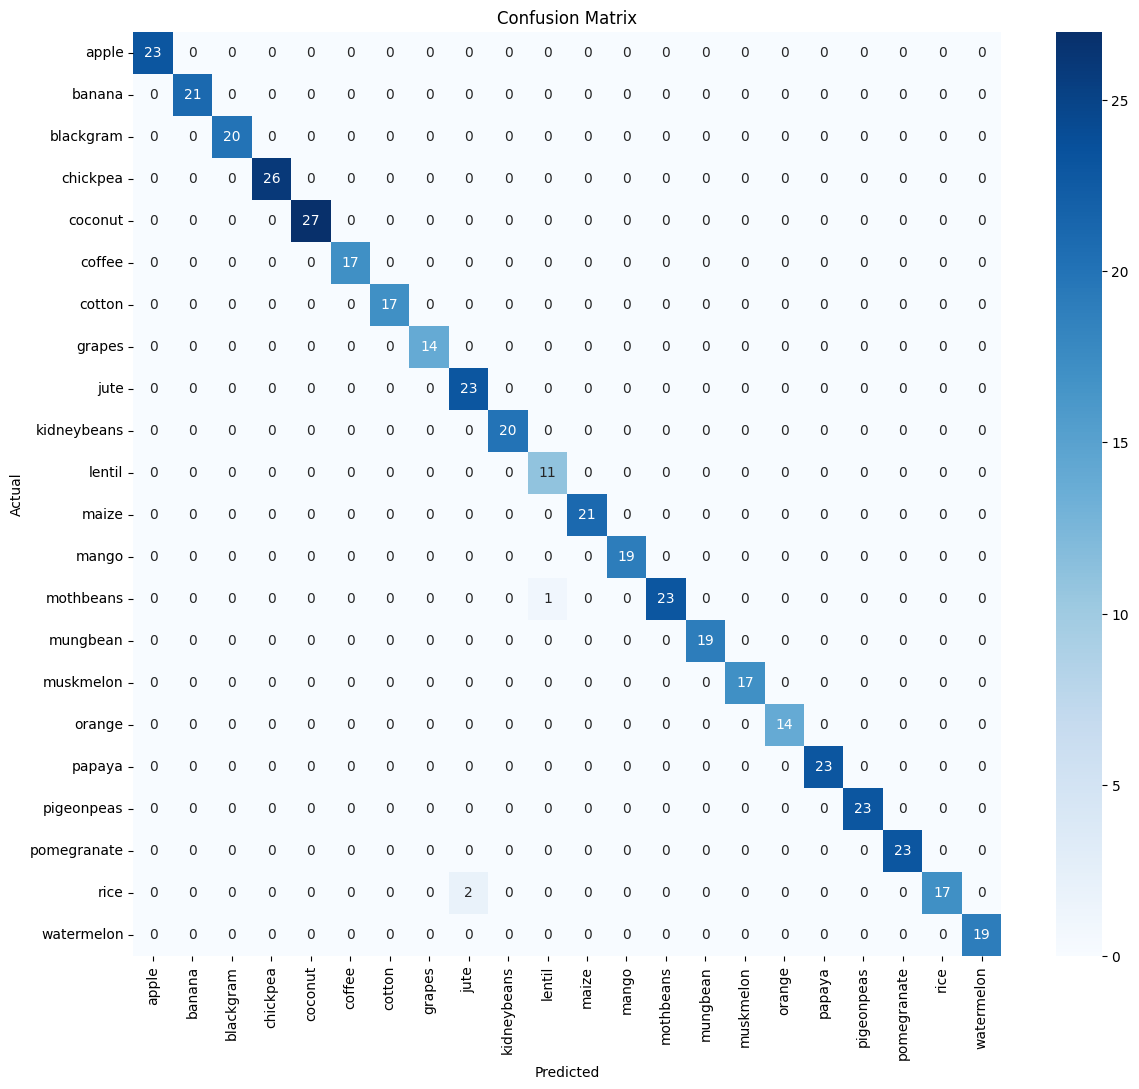

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

That diagonal is the dream of every ML engineer.

Why?

Because every blue square means

Actual == Predicted

So your model is predicting most crops correctly.

In [ ]:
#row ==> actuual value -- reality -- recall(the amount of predicted values from total)
#column => predicted value -- precision

In [ ]:
'''
Why Did Rice Become Jute?

Now comes the interesting question.

Imagine these values.

Feature	Rice	Jute
Nitrogen	82	80
Humidity	84	83
Rainfall	210	205
pH	6.4	6.5

Do these look similar?

YES.

Random Forest sees similar feature values.

So for 2 samples, it thought

"This looks more like Jute."

It wasn't random.

It made a decision based on learned patterns.
'''

## Why does **Random Forest work** so well?

Because one tree is like one person's opinion.

A forest is like asking many experts and choosing the majority answer.

Many independent opinions usually reduce mistakes.

feature importance,many decision trees,overfitting,nonlinear decision